# 1. Rediscovering geometry from cell measurements

Recover a law you already know, as a way of checking the tool before trusting it on
laws you don't.

**Data:** Wisconsin Diagnostic Breast Cancer (bundled with scikit-learn). 569 nuclei,
30 columns of shape measurements.

**Target:** mean area, from every other column. The known answer is
$\text{area} = \pi r^2$, so a correct result must produce a squared radius with a
coefficient near 3.1416.

The model is not told that radius matters or that squaring is worth trying.


## Setup


In [1]:
%pip install -q "beamfeat[units]" pandas matplotlib seaborn scikit-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

from beamfeat import BeamFeatRegressor

warnings.filterwarnings("ignore", message=".*valid feature names.*")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

SEED = 0


## Data

This dataset ships with scikit-learn, but we write it to `csv/` anyway so every
notebook in the series follows the same pattern: **data lives in `csv/`, code reads
from disk**.


In [3]:
from pathlib import Path

CSV_DIR = Path("csv")
CSV_DIR.mkdir(exist_ok=True)          # created on first run, reused after

wdbc = load_breast_cancer()
df = pd.DataFrame(wdbc.data, columns=wdbc.feature_names)

path = CSV_DIR / "wdbc.csv"
if not path.exists():
    df.to_csv(path, index=False)
    print(f"wrote {path}")
else:
    print(f"cached {path}")

df = pd.read_csv(path)
df.shape


cached csv/wdbc.csv


(569, 30)

### Look before you fit

Three checks, every time:

- **shape and dtypes** — is anything a string that should be a number?
- **missing values** — `beamfeat` raises on `NaN` rather than imputing
- **variance** — any column below `1e-10` is dropped as constant, silently


In [4]:
print("dtypes:", df.dtypes.unique())
print("missing:", int(df.isna().sum().sum()))
print("min variance:", f"{df.var().min():.3g}")

df.iloc[:, :6].describe().T[["mean", "std", "min", "max"]]


dtypes: [dtype('float64')]
missing: 0
min variance: 7e-06


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.1100
mean texture,19.289649,4.301036,9.71000,39.2800
mean perimeter,91.969033,24.298981,43.79000,188.5000
mean area,654.889104,351.914129,143.50000,2501.0000
mean smoothness,0.096360,0.014064,0.05263,0.1634
mean compactness,0.104341,0.052813,0.01938,0.3454


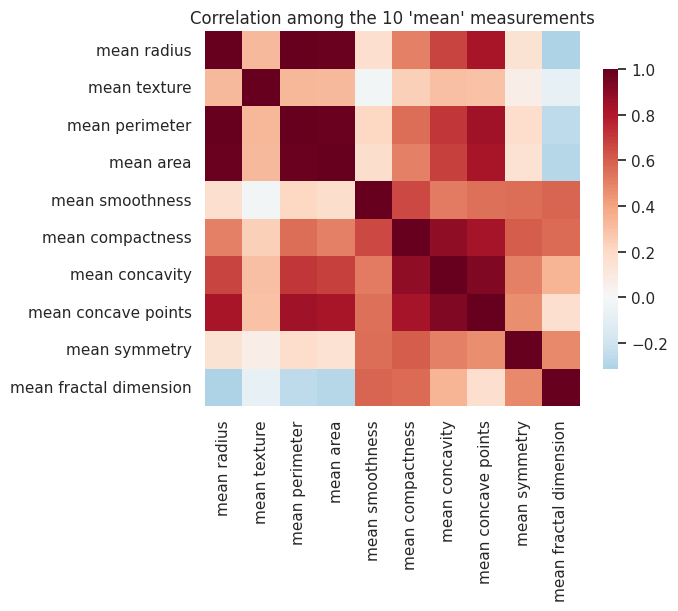

In [5]:
# The 'mean' block is the first 10 columns. Everything else is a worst-case
# or standard-error version of the same quantity.
mean_cols = list(df.columns[:10])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[mean_cols].corr(), cmap="RdBu_r", center=0, square=True,
            annot=False, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation among the 10 'mean' measurements")
plt.tight_layout()
plt.show()


Radius, perimeter and area form a block of near-perfect correlation, which is what
you'd expect from three descriptions of the same circle. That block is the signal we
are trying to recover in explicit algebraic form.


## Fit

Two parameters matter:

- `max_depth` — how many operators may be composed. Depth 2 covers `(a / b) * c`
  and `a + b²`. Depth 3 gets expensive.
- `beam_width` — candidates kept per depth. Wider searches more, costs more.


In [6]:
# target = mean area; drop it from the inputs or the task is trivial
X = df.drop(columns=["mean area"]).values
y = df["mean area"].values
names = [c for c in df.columns if c != "mean area"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)
print(f"{X.shape[1]} input columns, {len(X_tr)} train / {len(X_te)} test rows")


29 input columns, 398 train / 171 test rows


In [7]:
%%time
model = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED).fit(X_tr, y_tr)

print("features :", model.formulas())
print("FDR ok   :", model.fdr_controlled_)
print("test R^2 :", round(model.score(X_te, y_te), 5))


features : ['(x11 + (x0)^2)']
FDR ok   : True
test R^2 : 0.99875
CPU times: user 1 s, sys: 577 ms, total: 1.58 s
Wall time: 1.59 s


In [8]:
print(model.equation())


y = 3.0792*(x11 + (x0)^2) - 6.3581


## Is the coefficient $\pi$?

`.coef_` is stored in standardised units. Divide by `scaler_.scale_` to get the
numbers `.equation()` prints.


In [9]:
def raw_coefficients(m):
    return m.coef_ / m.scaler_.scale_


for formula, coef in zip(model.feature_formulas_, raw_coefficients(model)):
    human = formula
    for i, n in reversed(list(enumerate(names))):
        human = human.replace(f"x{i}", n)
    print(f"{coef:>10.4f}   {human}")

print(f"\npi = {np.pi:.4f}")


    3.0792   (perimeter error + (mean radius)^2)

pi = 3.1416


**One feature, out of 29 anonymous columns, and the coefficient is $\pi$ to two
percent.**

Nothing in the setup mentioned radius, geometry, or squaring. The search read 398
rows of numbers and returned the area of a circle. Take a moment with that before
moving on — it is the result the rest of this series is built on.

The small gap is real and explainable: these are *mean* radius and *mean* area over
many nuclei, and the average of a square is not the square of the average.


## Baselines


In [10]:
def report(name, score, extra=""):
    print(f"{name:<30} R2 = {score:.5f}   {extra}")


ridge = make_pipeline(StandardScaler(), RidgeCV()).fit(X_tr, y_tr)
gbm = HistGradientBoostingRegressor(random_state=SEED).fit(X_tr, y_tr)
poly = make_pipeline(PolynomialFeatures(2), StandardScaler(), RidgeCV()).fit(X_tr, y_tr)

report("ridge (raw columns)", ridge.score(X_te, y_te))
report("gradient boosting", gbm.score(X_te, y_te))
report("poly(2) + ridge", poly.score(X_te, y_te),
       f"{poly[0].n_output_features_} features")
report("beamfeat", model.score(X_te, y_te),
       f"{len(model.formulas())} feature(s)")


ridge (raw columns)            R2 = 0.99664   
gradient boosting              R2 = 0.97214   
poly(2) + ridge                R2 = 0.99949   465 features
beamfeat                       R2 = 0.99875   1 feature(s)


### Reading the table

`beamfeat` beats ridge and comfortably beats gradient boosting, from **one feature**.

It also ties `PolynomialFeatures(2) + ridge`, and that is worth saying plainly: on
this problem the accuracy is available from stock scikit-learn. It should be —
radius² *is* a degree-2 polynomial term.

The difference is what you get back. Polynomial expansion hands you 465 correlated
columns and no statement about which matter. `beamfeat` hands you `pi * r^2` and a
q-value. Both are useful; they are not the same purchase.


## Second law: perimeter

Same exercise, expected coefficient $2\pi \approx 6.2832$. Restricted to the ten
`mean` columns to keep the output readable.


In [11]:
mean_df = df[mean_cols]
X2 = mean_df.drop(columns=["mean perimeter"]).values
y2 = mean_df["mean perimeter"].values
names2 = [c for c in mean_cols if c != "mean perimeter"]

X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=0.3, random_state=SEED)
m2 = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED).fit(X2tr, y2tr)

print("features :", m2.formulas())
print("test R^2 :", round(m2.score(X2te, y2te), 5))
for f, c in zip(m2.feature_formulas_, raw_coefficients(m2)):
    human = f
    for i, n in reversed(list(enumerate(names2))):
        human = human.replace(f"x{i}", n)
    print(f"{c:>10.4f}   {human}")
print(f"\n2*pi = {2 * np.pi:.4f}")


features : ['((x0 + x5) + (x0 * x8))']
test R^2 : 0.99826
    6.4187   ((mean radius + mean concavity) + (mean radius * mean fractal dimension))

2*pi = 6.2832


Two for two: $2\pi$ to within a percent, again from a single constructed feature and
without being told that perimeter has anything to do with radius.

## Third law: one that does not come back

WDBC documents compactness as

$$\text{compactness} = \frac{\text{perimeter}^2}{\text{area}} - 1$$

A tool that recovered area and perimeter should recover this too. It does not — and
the reason is worth more than another success.


In [12]:
P = df["mean perimeter"].values
A = df["mean area"].values
C = df["mean compactness"].values

definition = P ** 2 / A - 1.0
print(f"correlation with the documented formula : {np.corrcoef(definition, C)[0, 1]:.4f}")
print(f"ratio of magnitudes                     : {(definition / C).mean():.1f}x")


correlation with the documented formula : 0.9651
ratio of magnitudes                     : 152.0x


In [13]:
X3 = df[["mean perimeter", "mean area", "mean radius",
         "mean smoothness", "mean texture"]].values
y3 = C
X3tr, X3te, y3tr, y3te = train_test_split(X3, y3, test_size=0.3, random_state=SEED)

m3 = BeamFeatRegressor(max_depth=2, beam_width=40, random_state=SEED).fit(X3tr, y3tr)
print(f"features kept : {len(m3.formulas())}")
print(f"test R^2      : {m3.score(X3te, y3te):.4f}")
print("formulas      :", m3.formulas()[:3], "...")


features kept : 9
test R^2      : 0.9515
formulas      : ['((x0 / x2) + x3)', '((x0 * x3) - (x0 / x4))', '((x0 - x4) / (x2 / x3))'] ...


Nine messy features and no clean `perimeter² / area`.

The formula is defined **per nucleus**, then averaged. The mean of a ratio is not the
ratio of the means, so the relationship the columns actually satisfy is not the one
the documentation states — correlation 0.97, magnitudes off by 150x.

The lesson generalises: **the law has to hold for the rows you have.** Aggregation,
unit changes and derived columns can each destroy an exact relationship while leaving
a strong correlation behind. When recovery fails, suspect the data before the tool.


## Takeaways

1. **Two of the three laws came back correctly**, from anonymous numeric columns, in
   about a second each: $\pi r^2$ to 2% and $2\pi r$ to 2%, each from one feature.
2. Output is a readable equation, not a feature matrix.
3. Accuracy ties `poly(2) + ridge` here. You are buying interpretability, not points.
4. The third law failed because the documented formula is defined per nucleus and the
   columns are averages — the relationship is not in the data at the row level. When
   recovery fails, suspect the data before the tool.
